The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


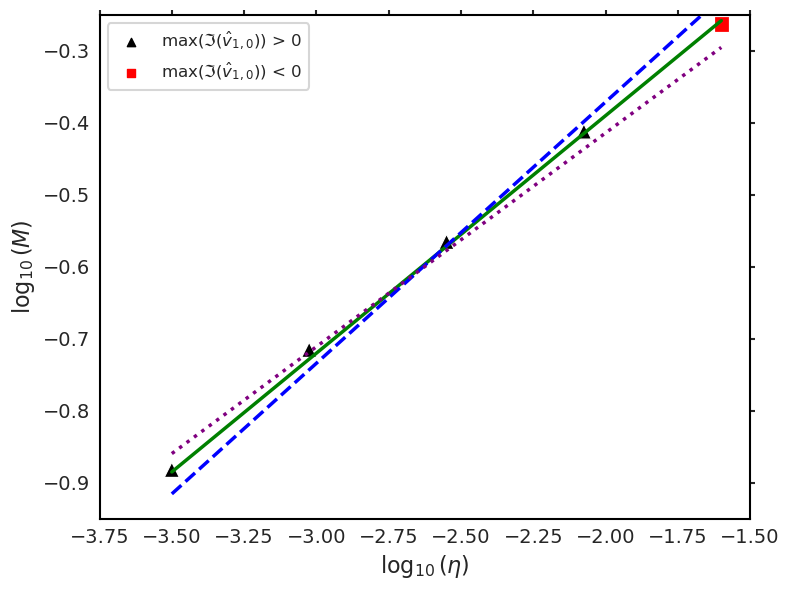

In [3]:
#!/usr/bin/env python3
"""
Example script for scaling law plots

Public version with randomly generated data for demonstration.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# -----------------------------
# Synthetic data points
# -----------------------------
np.random.seed(0)
n_points = 5

# Main scaling line
line_slope = 0.33
line_intercept = 0.27
line_x = np.linspace(-3.5, -1.6, n_points)
line_y = line_slope * line_x + line_intercept

# Small deviations above/below line
delta = 0.03
y_offsets = np.random.uniform(-delta, delta, n_points)

# Assign behaviour type
behaviour_type = ['max($\Im(\hat{v}_{1,0})$) > 0' if offset>0 else 'max($\Im(\hat{v}_{1,0})$) < 0' for offset in y_offsets]

# Build DataFrame
df = pd.DataFrame({
    'log_eta': line_x,
    'log_M': line_y + y_offsets,
    'behaviour_type': behaviour_type
})

# -----------------------------
# Plotting
# -----------------------------
sns.set_style('white')
fig, ax = plt.subplots(figsize=(8,6))

# Scatter plot
sns.scatterplot(
    x='log_eta', y='log_M', data=df,
    hue='behaviour_type', style='behaviour_type',
    palette=['black', 'red'], markers=['^', 's'],
    s=120, alpha=1, ax=ax
)

# Spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Labels and ticks
ax.set_xlabel('$\log_{10}(\\eta)$', fontsize=16, fontweight='bold')
ax.set_ylabel('$\log_{10}(M)$', fontsize=16, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5, top=True, right=True)

# Legend
legend = ax.legend(loc="upper left", fontsize=12, title_fontsize=14, frameon=True)
legend.get_frame().set_linewidth(1.5)

# Reference scaling lines
line_y1 = 1.1 * line_slope * line_x + 0.355
line_y2 = 0.9 * line_slope * line_x + 0.18
ax.plot(line_x, line_y, color='green', ls='-', lw=2.5)
ax.plot(line_x, line_y1, color='blue', ls='--', lw=2.5)
ax.plot(line_x, line_y2, color='purple', ls=':', lw=2.5)

ax.set_xlim([-3.75, -1.5])
ax.set_ylim([-0.95, -0.25])
fig.tight_layout()

# Save figure
outdir = Path("figures")
outdir.mkdir(exist_ok=True)
fig.savefig(outdir / "2dsinx_scalinglaw.png", dpi=300)
fig.savefig(outdir / "2dsinx_scalinglaw.eps", dpi=300)

plt.show()
